<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/work/notebooks/ExploratoryDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


## Exploratory Data Analysis

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

In [16]:
df.head(5)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


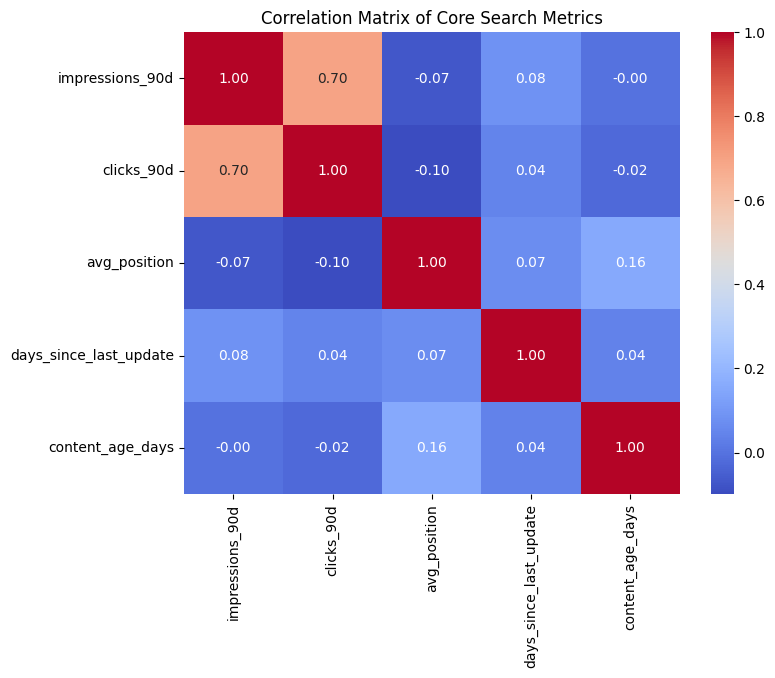

In [17]:
# Isolate numerical columns for correlation
core_metrics = ['impressions_90d', 'clicks_90d', 'avg_position', 'days_since_last_update', 'content_age_days']
corr_matrix = df[core_metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Core Search Metrics")
plt.show()

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
# Referencing the dataset specifically as requested
file_name = "FlyRank"
try:
    df = pd.read_csv(file_name)
    print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print(f"Please ensure {file_name} is in the current working directory.")

# Assuming successful load, let's create our binary target label
if 'trend_direction' in df.columns:
    df['is_declining'] = (df['trend_direction'].str.lower() == 'down').astype(int)

# 2. Distribution Analysis (Handling Heavy Tails)
def plot_distributions(df):
    plt.figure(figsize=(12, 5))

    # Impressions (Log Scale due to massive outliers)
    plt.subplot(1, 2, 1)
    sns.histplot(df['impressions_90d'], bins=50, log_scale=True, color='blue')
    plt.title('Distribution of 90-Day Impressions (Log Scale)')
    plt.xlabel('Log Impressions')

    # Average Position
    plt.subplot(1, 2, 2)
    sns.histplot(df['avg_position'], bins=50, color='orange')
    plt.title('Distribution of Average Position')
    plt.xlabel('Average Position')

    plt.tight_layout()
    plt.show()

# 3. Feature Interaction: The Danger Zone & Freshness
def plot_danger_zone(df):
    # Binning position into quartiles to see the non-linear decay cliff
    df['pos_bin'] = pd.qcut(df['avg_position'], q=4, duplicates='drop')
    decay_rates = df.groupby('pos_bin')['is_declining'].mean() * 100

    plt.figure(figsize=(8, 4))
    decay_rates.plot(kind='bar', color='crimson')
    plt.title('Traffic Decay Rate by Ranking Position Quartile')
    plt.ylabel('% of Pages Declining')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4. Correlation Heatmap (Pre-Window Signals Only)
def plot_correlation(df):
    core_features = ['impressions_90d', 'avg_position', 'days_since_last_update', 'content_age_days', 'is_declining']
    corr = df[core_features].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Correlation Matrix of Core Search Metrics')
    plt.tight_layout()
    plt.show()

Please ensure FlyRank is in the current working directory.


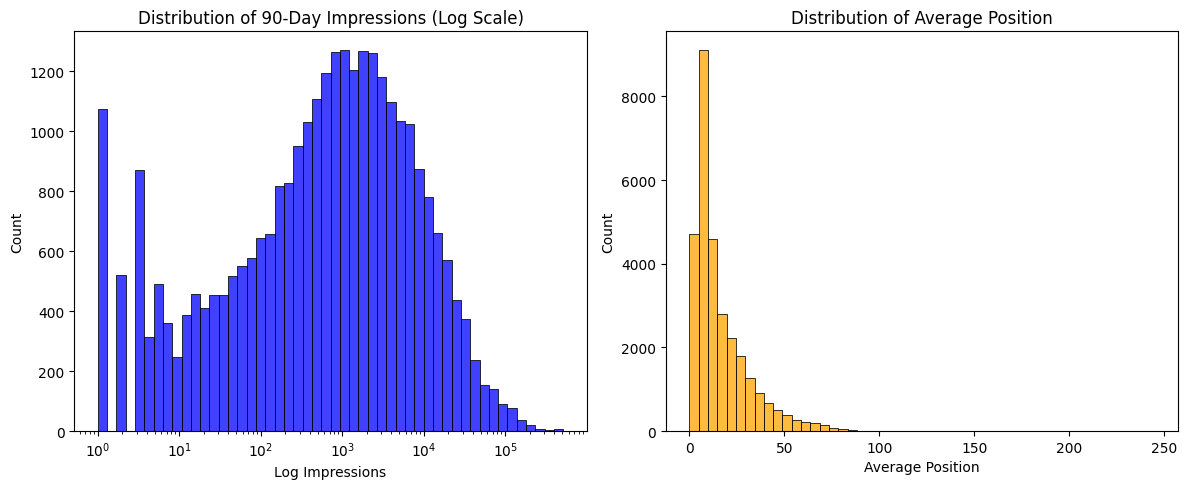

In [19]:
plot_distributions(df)

/tmp/ipykernel_654/4171250406.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decay_rates = df.groupby('pos_bin')['is_declining'].mean() * 100


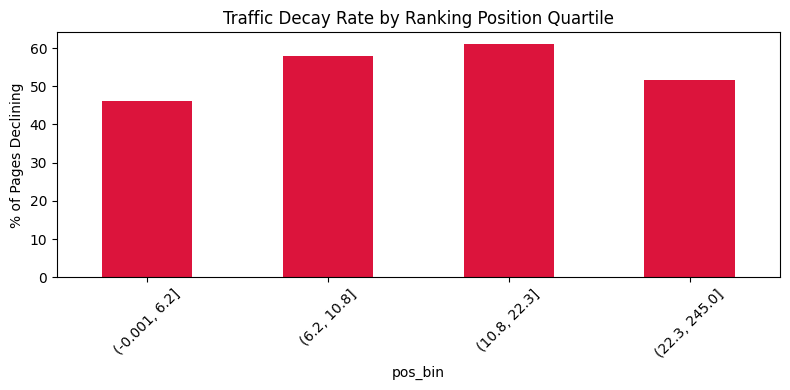

In [20]:
plot_danger_zone(df)

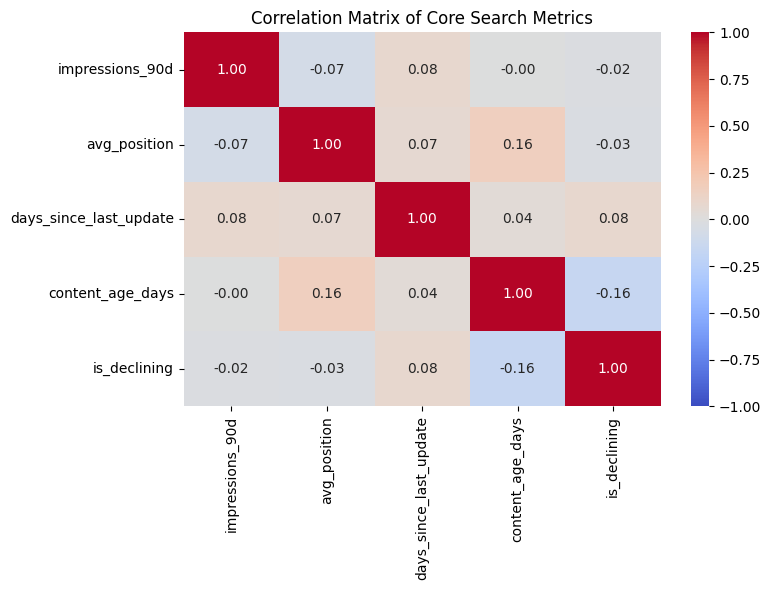

In [21]:
plot_correlation(df)